In [85]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split


In [86]:
titanic=sns.load_dataset("titanic")

In [87]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [88]:
titanic.describe()
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [89]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [90]:
features=["sex","fare","pclass","embarked","age"]
target=["survived"]

In [91]:
#missing data

from sklearn.impute import SimpleImputer
imp_median=SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])
imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

In [92]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
titanic["embarked"]=le.fit_transform(titanic["embarked"])
titanic["sex"]=le.fit_transform(titanic["sex"])


In [93]:
X=titanic[features]
y=titanic[target]

In [94]:
X_train,X_test,y_train,y_test=train_test_split( X,y,test_size=0.2 , random_state=42)

In [95]:
#Decision Tree Model-no pruning
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [96]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(X_test)

print("accuracy :",accuracy_score(y_test,y_pred))


accuracy : 0.7597765363128491


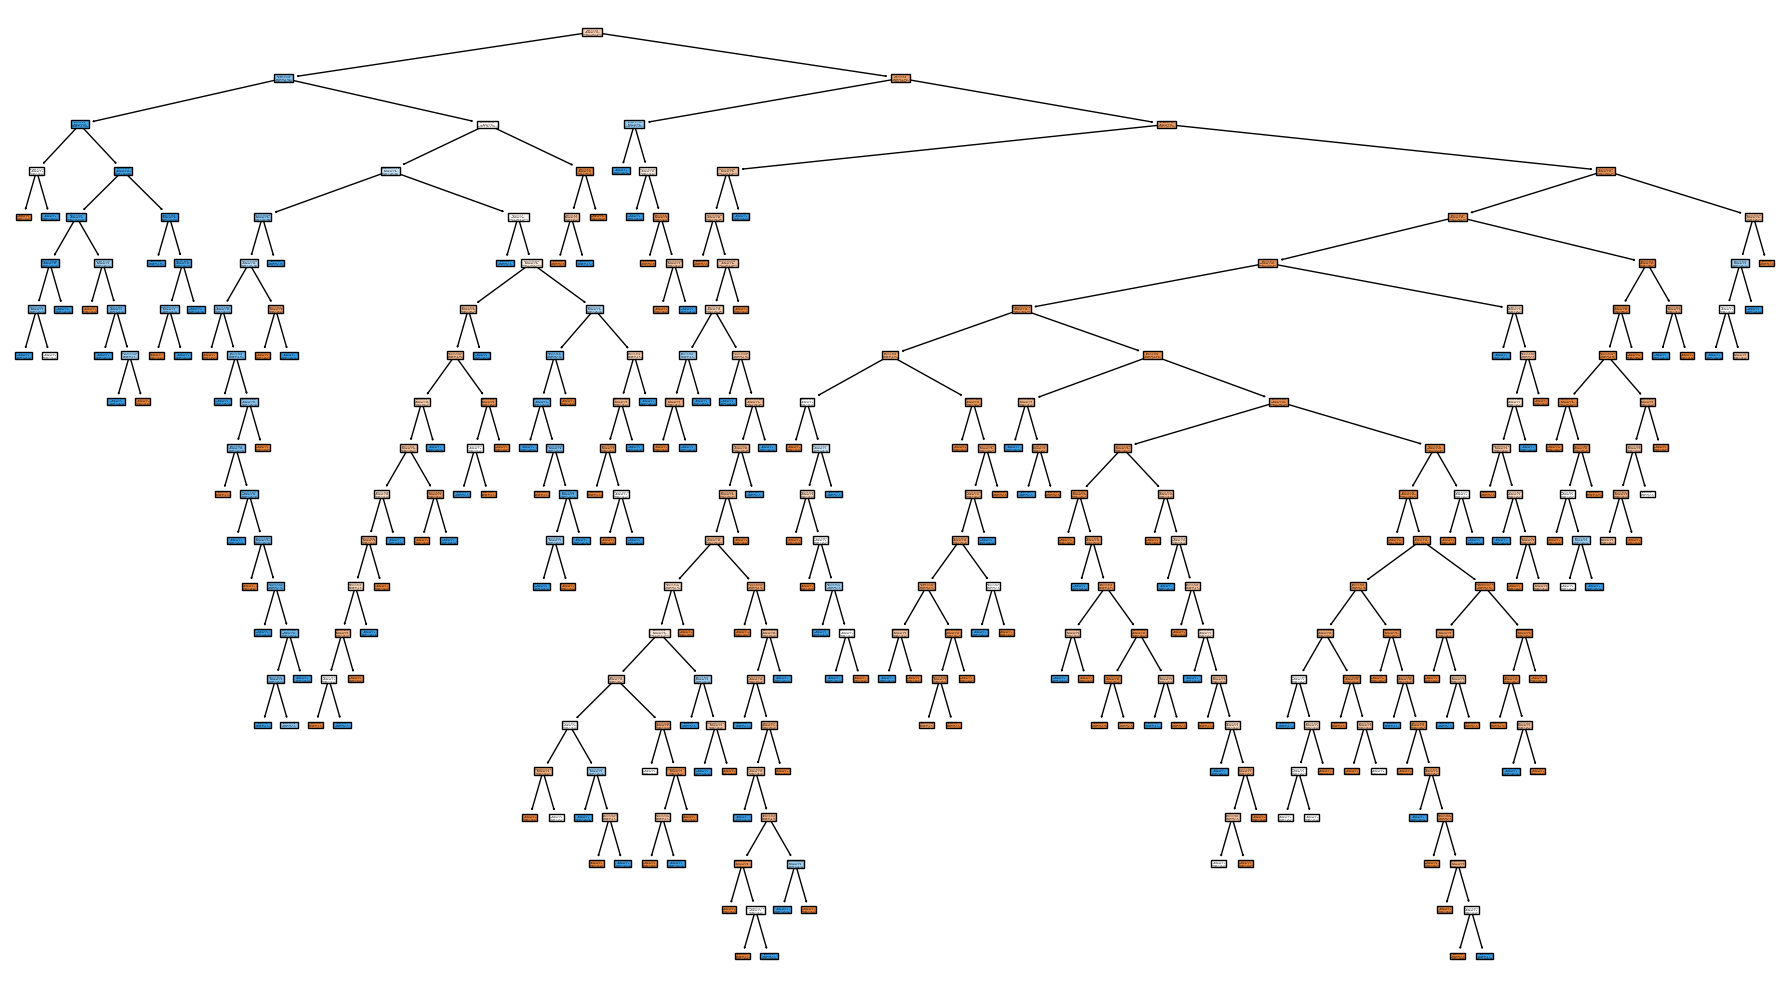

In [97]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)

plt.tight_layout()
plt.show()


for depth = 3, accuracy = 0.7988826815642458
for depth = 5, accuracy = 0.7988826815642458


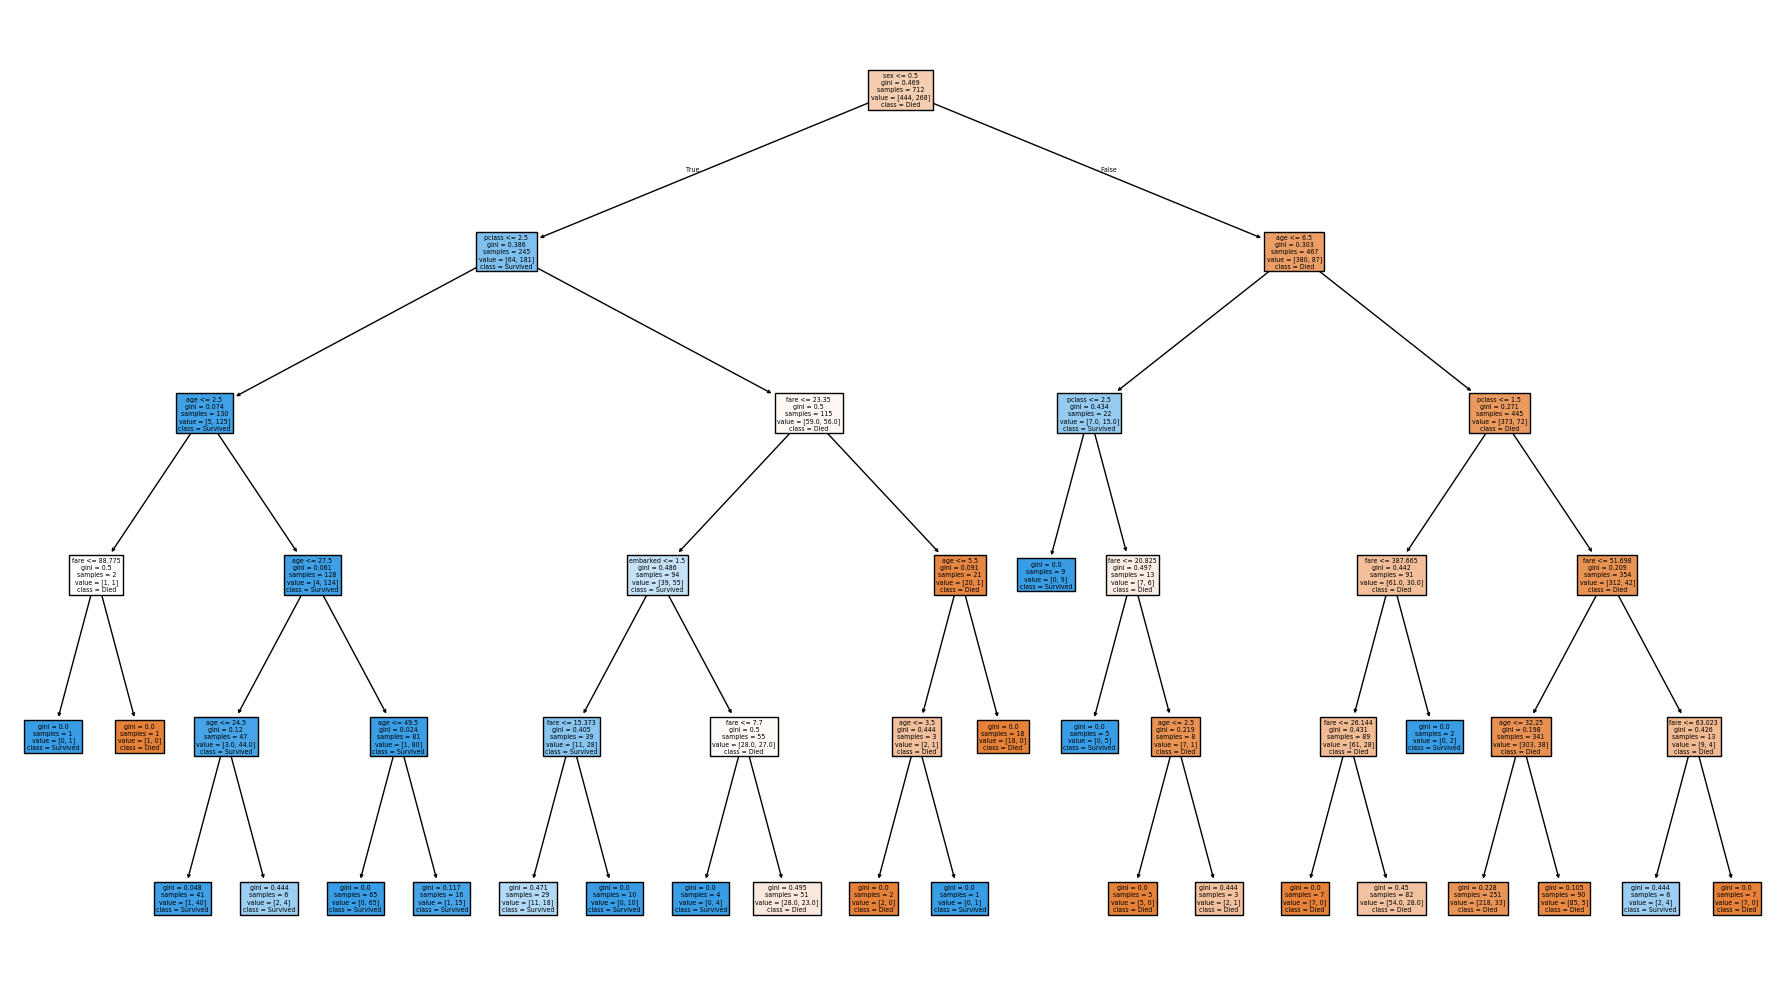

for depth = 6, accuracy = 0.8044692737430168
for depth = 7, accuracy = 0.7932960893854749
for depth = 8, accuracy = 0.7988826815642458
for depth = 9, accuracy = 0.7988826815642458
for depth = 14, accuracy = 0.770949720670391
for depth = 40, accuracy = 0.770949720670391
for depth = 99, accuracy = 0.770949720670391


In [105]:
max_depths = [3, 5, 6, 7, 8, 9, 14, 40, 99]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"for depth = {depth}, accuracy = {acc}")

    # plot only for one chosen depth
    if depth == 5:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True
        )
        plt.tight_layout()
        plt.show()

In [106]:
#decision tree post-pruning
full_tree= DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)


DecisionTreeClassifier(random_state=42)

In [108]:
path=full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas=path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [110]:
tree=[]
for alpha in ccp_alphas:
     model = DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
     model.fit(X_train,y_train)
     acc=model.score(X_test,y_test)
     tree.append((model,acc))
    

In [111]:
best_acc=0
best_alpha=0

for model,alpha in tree:
    curr_acc=model.score(X_test,y_test)
    if curr_acc>best_acc:
        best_acc=curr_acc
        best_alpha=alpha


In [112]:
best_alpha

0.8379888268156425